In [ ]:
!pip install statannot
!pip install scikit-optimize

from __future__ import division
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
from xgboost import plot_importance
import plotly.graph_objects as go
from tqdm.notebook import tqdm
from sklearn.model_selection import RepeatedKFold
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, accuracy_score, recall_score, precision_score, confusion_matrix, mean_squared_error
import seaborn as sns
from statannot import add_stat_annotation
from sklearn.linear_model import Lasso, MultiTaskLasso, Ridge, ElasticNet

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import mutual_info_regression, f_regression

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedKFold
from sklearn.decomposition import PCA

from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler

from sklearn import metrics


from skopt import BayesSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet

import statsmodels.api as sm

import time

import scipy

from sklearn.svm import SVR

from skopt import BayesSearchCV
from sklearn.ensemble import RandomForestRegressor

from statsmodels.stats.multitest import fdrcorrection

from statsmodels.stats import multitest

from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
from sklearn.ensemble import ExtraTreesClassifier

from collections import Counter
import heapq

import statsmodels.api as sm

from sklearn.ensemble import RandomForestRegressor

import re

from sklearn.preprocessing import MinMaxScaler

import os

from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

import shap

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.0 MB/s eta 0:00:00


## Bayes Search

In [ ]:
from skopt import BayesSearchCV
def SearchBestModel(case_x, case_y):

    X_train, X_test, y_train, y_test = train_test_split(case_x, case_y, test_size=.1, random_state=42)

    opt_XGB = BayesSearchCV(
            XGBClassifier(),
             {
                'objective': ['binary:logistic'],
                'eval_metric': ['logloss', 'error', 'auc', 'aucpr'],
                'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
                'max_depth': [2, 3, 4, 5, 6],
                'subsample': [0.7, 0.8, 0.9, 1.0],
                'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
                'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
                'reg_lambda': [0, 0.01, 0.1, 0.5, 1.0],
                'gamma': [0, 0.001, 0.01, 0.1, 1],
                'min_child_weight': [1, 3, 5],
                'n_estimators': [100, 200, 300, 500]
            },

            n_iter=10,
            cv=7,
            random_state=42
        )

    opt_XGB.fit(X_train, y_train)


    print('XGB')
    print("val. score: %s" % opt_XGB.best_score_)
    print("test score: %s" % opt_XGB.score(X_test, y_test))
    print("best parameters: %s" % str(opt_XGB.best_params_))
    print('---------------------------------------------\n')

    return opt_XGB

In [ ]:
from sklearn.svm import SVC
def SearchBestSVM(case_x, case_y):
    X_train, X_test, y_train, y_test = train_test_split(case_x, case_y, test_size=0.1, random_state=42)

    opt_SVM = BayesSearchCV(
        SVC(),
        {
            'C': [0.1, 1, 10, 100, 1000],
            'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
            #'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
            'degree': [2, 3, 4, 5],
            'coef0': [0.0, 0.1, 0.5, 1.0],  # for 'poly' and 'sigmoid'
            'shrinking': [True, False],  # Support optimization
            'tol': [1e-4, 1e-3, 1e-2],  # Convergence tolerance
        },
        n_iter=10,
        cv=5,
        random_state=42
    )

    opt_SVM.fit(X_train, y_train)

    print('SVM')
    print("val. score: %s" % opt_SVM.best_score_)
    print("test score: %s" % opt_SVM.score(X_test, y_test))
    print("best parameters: %s" % str(opt_SVM.best_params_))
    print('---------------------------------------------\n')

    return opt_SVM

## Reading, renaming, cleaning data

In [ ]:
df =  pd.read_excel(" ")
df.rename(columns={'AB40': 'Aβ40','AB42': 'Aβ42', 'ratioAB42/40': 'Aβ ratio', 'NfL': 'NfL','p-tau181': 'p-tau181', 'p-tau217': 'p-tau217', 'sex ': 'sex', 'Age': 'age', 'Education': 'education', 'Diagnosis': 'diagnosis' }, inplace=True)


In [ ]:
for i in df.columns:
    print(i)

record_id
site
Country
cdr_date
cdr_examiner
cdr_means
cdr_memory
cdr_orient
cdr_prblm
cdr_cmnaff
cdr_hobby
cdr_care
cdr_behav
cdr_lang
cdr_boxscore
cdr_ans
cdr_notans
cdr_enter_from_crf_complete
cdr_global_auto
Unnamed: 19
cog_date
cog_examiner
cog_means
cog_diag
cog_time
cog_ed
colors_ed
cat_ed___0
cat_ed___1
cat_ed___2
cat_ed___3
cat_ed___4
cat_ed___5
cat_ed___6
cat_ed___7
cat_ed___8
cog_occ
cog_occ_area
cog_occ_duties
cog_occ_yrs
cog_craft_verb
cog_craft_para
cog_benson
cog_digits_forward_total
cog_digits_forward_span
cog_digits_backward_total
cog_digits_backward_span
cog_category_animals
cog_category_vegetables
cog_tmt_a
cog_tmt_a_err
cog_tmt_a_corr
cog_tmt_b
cog_tmt_b_err
cog_tmt_b_corr
cog_craft_verb_delayed
cog_craft_para_delayed
cog_craft_para_delayed_min
cog_craft_para_delayed_cue
cog_benson_delay
cog_benson_recog
cog_mint_total
cog_mint_total_wosemantic
cog_mint_semantic_num
cog_mint_semantic_corr
cog_mint_phonemic_num
cog_mint_phonemic_corr
cog_verbal1_corr
cog_verbal1_reps

In [ ]:
df.dropna(subset=['Aβ ratio', 'Aβ40', 'Aβ42', 'NfL', 'p-tau181', 'p-tau217', 'diagnosis', 'sex', 'age', 'education'], inplace=True)
df

,record_id,site,Country,cdr_date,cdr_examiner,cdr_means,cdr_memory,cdr_orient,cdr_prblm,cdr_cmnaff,...,p-tau181,NfL,Aβ40,Aβ42,Aβ ratio,p-tau217,sex,age,education,diagnosis
0,AF023,Avila,Mexico,2021-08-28,DDuron,1.0,0.0,0.0,0.0,0.0,...,1.05,19.66,278.62,21.90,0.078602,0.194,1.0,72.0,6.0,CN
1,AF025,Avila,Mexico,2021-08-29,DDuron,1.0,0.0,0.0,0.0,0.0,...,5.26,27.29,324.78,30.09,0.092647,0.112,2.0,75.0,16.0,CN
3,AF033,Avila,Mexico,2021-11-15,DDuron,1.0,0.0,0.0,0.0,0.0,...,1.62,41.81,587.07,54.19,0.092306,0.157,1.0,57.0,16.0,CN
4,AF039,Avila,Mexico,2021-11-24,DDuron,1.0,0.0,0.0,0.0,0.0,...,0.65,16.66,160.99,16.23,0.100814,0.154,1.0,64.0,25.0,CN
6,AF045,Avila,Mexico,2021-12-01,DDuron,1.0,0.0,0.0,0.0,0.0,...,1.99,18.38,217.91,20.60,0.094534,0.185,2.0,62.0,18.0,CN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,RE057,NaN,Brazil,2023-11-23 00:00:00,LASaraiva,1.0,1.0,0.0,0.5,0.5,...,0.96,45.05,309.98,33.75,0.108878,0.090,2.0,75.0,4.0,FTD
701,RE067,NaN,Brazil,2024-03-22 00:00:00,LASaraiva,1.0,1.0,0.5,0.5,0.5,...,1.90,30.30,535.48,41.24,0.077015,0.177,2.0,79.0,4.0,FTD
702,RE086,NaN,Brazil,NaN,NaN,NaN,0.5,0.5,0.5,0.5,...,1.12,17.78,342.62,25.99,0.075857,0.080,2.0,66.0,16.0,FTD
703,RE089,NaN,Brazil,2024-08-23 00:00:00,LASaraiva,1.0,0.5,0.5,1.0,1.0,...,4.61,82.65,648.86,48.18,0.074253,0.353,2.0,70.0,4.0,FTD


In [ ]:
Counter(df.diagnosis)

Counter({'CN': 209, 'AD': 223, 'FTD': 137})

### Outliers drop

In [ ]:
df['mmse_educ'] = df['mmse_total']*df['education']

In [ ]:
df_CN = df[df['diagnosis'] == 'CN'].copy()
Q1 = df_CN['mmse_educ'].quantile(0.25)
Q3 = df_CN['mmse_educ'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_CN = df_CN[(df_CN['mmse_educ'] >= lower_bound) & (df_CN['mmse_educ'] <= upper_bound)]
df_CN.reset_index(inplace = True, drop = True)
df_CN.shape

(202, 252)

In [ ]:
df_AD = df[df['diagnosis'] == 'AD'].copy()
Q1 = df_AD['mmse_educ'].quantile(0.25)
Q3 = df_AD['mmse_educ'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_AD = df_AD[(df_AD['mmse_educ'] >= lower_bound) & (df_AD['mmse_educ'] <= upper_bound)]
df_AD.reset_index(inplace = True, drop = True)
df_AD.shape

(223, 252)

In [ ]:
df_FTD = df[df['diagnosis'] == 'FTD'].copy()
Q1 = df_FTD['mmse_educ'].quantile(0.25)
Q3 = df_FTD['mmse_educ'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_FTD = df_FTD[(df_FTD['mmse_educ'] >= lower_bound) & (df_FTD['mmse_educ'] <= upper_bound)]
df_FTD.reset_index(inplace = True, drop = True)
df_FTD.shape

(134, 252)

In [ ]:
df = pd.concat([df_CN, df_AD, df_FTD], axis = 0)

In [ ]:
df.reset_index(inplace = True, drop = True)

In [ ]:
df_neuro_complete = pd.read_excel(" ")

In [ ]:
df_neuro_complete = df_neuro_complete[['record_id','cog_craft_verb_delayed', 'cog_tmt_b', 'cog_benson']]


In [ ]:
df_neuro_complete['cog_tmt_b'] = np.where(df_neuro_complete['cog_tmt_b'] > 300, np.nan, df_neuro_complete['cog_tmt_b'])
df_neuro_complete['cog_craft_verb_delayed'] = np.where(df_neuro_complete['cog_craft_verb_delayed'] > 44, np.nan, df_neuro_complete['cog_craft_verb_delayed'])
df_neuro_complete['cog_benson'] = np.where(df_neuro_complete['cog_benson'] > 17, np.nan, df_neuro_complete['cog_benson'])
df_neuro_complete.dropna(inplace = True)
df_neuro_complete.reset_index(inplace = True, drop = True)

df_neuro_complete = df_neuro_complete.rename(columns = {'cog_craft_verb_delayed': 'Memory', 'cog_tmt_b': 'ExecutiveFunction', 'cog_benson':'Visuospatial'})

In [ ]:
df_atrophy = pd.read_excel(" ")
df_atrophy['ID'] = df_atrophy['ID'].str.replace('sub-', '')
df_atrophy.rename(columns={'ID': 'record_id'}, inplace=True)

,record_id,TIV,Atrophy/total,Rectus L,Rectus R,Hippocampus L,Hippocampus R
0,AF023,1360.81,0.437240,0.001750,0.001577,0.002989,0.002750
1,AF024,1220.30,0.429165,0.001621,0.001275,0.002745,0.002291
2,AF025,1580.44,0.384045,0.001684,0.001322,0.002652,0.002487
3,AF026,1227.19,0.354965,0.001261,0.001128,0.001455,0.001451
4,AF027,1164.67,0.380013,0.001335,0.001287,0.002508,0.002055
...,...,...,...,...,...,...,...
2729,SL00507,1173.16,0.471837,0.001872,0.001676,0.003176,0.002940
2730,SL00512,1642.66,0.400259,0.001482,0.001226,0.002647,0.002423
2731,SL00519,1347.86,0.433866,0.001989,0.001524,0.002996,0.002735
2732,SL00527,1425.58,0.359089,0.000887,0.000790,0.002023,0.001532


In [ ]:
df = pd.merge(df, df_neuro_complete, on = 'record_id', how = 'inner')
df = pd.merge(df, df_atrophy, on = 'record_id', how = 'inner')
df

,record_id,site,Country,cdr_date,cdr_examiner,cdr_means,cdr_memory,cdr_orient,cdr_prblm,cdr_cmnaff,...,mmse_educ,Memory,ExecutiveFunction,Visuospatial,TIV,Atrophy/total,Rectus L,Rectus R,Hippocampus L,Hippocampus R
0,AF023,Avila,Mexico,2021-08-28,DDuron,1.0,0.0,0.0,0.0,0.0,...,168.0,11.0,300.0,16.0,1360.81,0.437240,0.001750,0.001577,0.002989,0.002750
1,AF025,Avila,Mexico,2021-08-29,DDuron,1.0,0.0,0.0,0.0,0.0,...,464.0,11.0,197.0,14.0,1580.44,0.384045,0.001684,0.001322,0.002652,0.002487
2,AF033,Avila,Mexico,2021-11-15,DDuron,1.0,0.0,0.0,0.0,0.0,...,448.0,18.0,69.0,15.0,1265.06,0.445410,0.001792,0.001636,0.002922,0.002641
3,AF039,Avila,Mexico,2021-11-24,DDuron,1.0,0.0,0.0,0.0,0.0,...,700.0,12.0,61.0,15.0,1392.27,0.411996,0.001684,0.001265,0.002901,0.002829
4,AF045,Avila,Mexico,2021-12-01,DDuron,1.0,0.0,0.0,0.0,0.0,...,540.0,11.0,300.0,12.0,1550.50,0.408320,0.001712,0.001353,0.002793,0.002489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,RE041,NaN,Brazil,2023-07-28 00:00:00,LASaraiva,1.0,1.0,1.0,1.0,1.0,...,364.0,0.0,89.0,17.0,1642.11,0.398822,0.001677,0.001491,0.001992,0.001777
253,RE049,NaN,Brazil,2023-12-07 00:00:00,LASaraiva,1.0,0.5,0.0,1.0,1.0,...,275.0,15.0,300.0,16.0,1503.04,0.333511,0.001477,0.001263,0.002417,0.002286
254,RE054,NaN,Brazil,2023-11-24 00:00:00,LASaraiva,1.0,0.5,0.5,1.0,1.0,...,540.0,5.0,300.0,13.0,1400.41,0.389100,0.001425,0.001273,0.002126,0.002079
255,RE067,NaN,Brazil,2024-03-22 00:00:00,LASaraiva,1.0,1.0,0.5,0.5,0.5,...,100.0,11.0,230.0,13.0,1744.69,0.386453,0.001525,0.001246,0.002079,0.001829


In [ ]:
df['ExecutiveFunction'] = df['ExecutiveFunction'].max() - df['ExecutiveFunction']

#Saving all df processing to save time:
df.to_excel(' ')

### Class definition

In [ ]:
df=pd.read_excel(' ')

df_ad_ftd = df.copy()
df_ad_ftd['diagnosis'] = df_ad_ftd['diagnosis'].map({'CN': 0, 'AD': 1 ,'FTD': 2})
# Display the counts
diagnosis_counts = df_ad_ftd['diagnosis'].value_counts()
print("Number of instances of CN:", diagnosis_counts.get(0, 0))
print("Number of instances of AD:", diagnosis_counts.get(1, 0))
print("Number of instances of FTD:", diagnosis_counts.get(2, 0))

df_ad_ftd = df_ad_ftd[df_ad_ftd['diagnosis'] != 2]
df_ad_ftd.reset_index(inplace=True, drop = True)
df_ad_ftd.dropna(subset=['diagnosis'], inplace=True)
df_ad_ftd.reset_index(inplace=True, drop = True)

diagnosis_counts = df_ad_ftd['diagnosis'].value_counts()
# Display the counts
print("\n\nNumber of instances of CN:", diagnosis_counts.get(0, 0))
print("Number of instances of AD:", diagnosis_counts.get(1, 0))
print("Number of instances of FTD:", diagnosis_counts.get(2, 0))

Number of instances of CN: 104
Number of instances of AD: 95
Number of instances of FTD: 58


Number of instances of CN: 104
Number of instances of AD: 95
Number of instances of FTD: 0


In [ ]:
## For matched samples analysis
df=pd.read_csv('')
df=pd.read_excel('')

NameError: name 'df_ad_ftd' is not defined

In [ ]:
## For APOE aggregation data
df=pd.read_csv(' ')
df['ApoE'] = df['ApoE'].map({'E3/E3': 0, 'E3/E4': 1,'E4/E4': 2})



df_ad_ftd = df.copy()
df_ad_ftd['diagnosis'] = df_ad_ftd['diagnosis'].map({'CN': 0, 'AD': 1 ,'FTD': 2})
# Display the counts
diagnosis_counts = df_ad_ftd['diagnosis'].value_counts()
print("Number of instances of CN:", diagnosis_counts.get(0, 0))
print("Number of instances of AD:", diagnosis_counts.get(1, 0))
print("Number of instances of FTD:", diagnosis_counts.get(2, 0))

df_ad_ftd = df_ad_ftd[df_ad_ftd['diagnosis'] != 2]
df_ad_ftd.reset_index(inplace=True, drop = True)
df_ad_ftd.dropna(subset=['diagnosis'], inplace=True)
df_ad_ftd.reset_index(inplace=True, drop = True)

diagnosis_counts = df_ad_ftd['diagnosis'].value_counts()
# Display the counts
print("\n\nNumber of instances of CN:", diagnosis_counts.get(0, 0))
print("Number of instances of AD:", diagnosis_counts.get(1, 0))
print("Number of instances of FTD:", diagnosis_counts.get(2, 0))



Number of instances of CN: 114
Number of instances of AD: 154
Number of instances of FTD: 0


## SVM

### Optimal model

In [ ]:

interest_vars = ['','','']
k_feature = interest_vars

for var in interest_vars:
    df_ad_ftd[var] = pd.to_numeric(df_ad_ftd[var], errors='coerce')

df_ad_ftd[interest_vars] = df_ad_ftd[interest_vars].astype(float)


df_ad_ftd.dropna(inplace=True, subset= interest_vars)
df_ad_ftd.reset_index(inplace=True, drop = True)


X_ad_ftd = df_ad_ftd[interest_vars]
y_ad_ftd = df_ad_ftd['diagnosis']

scaler = MinMaxScaler((0.05, 0.95))
X_ad_ftd_s = scaler.fit_transform(X_ad_ftd)
X_ad_ftd = pd.DataFrame(X_ad_ftd_s, columns=interest_vars, index=X_ad_ftd.index)

X_train_ad_ftd, X_test_ad_ftd, y_train_ad_ftd, y_test_ad_ftd = train_test_split(X_ad_ftd, y_ad_ftd, test_size=0.1, random_state=42, stratify=y_ad_ftd)




In [ ]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'kernel': [ 'rbf'],
    'gamma': ['scale', 'auto'],

    'degree': [2, 3, 4, 5],  # Sonly for 'poly' kernel
    'coef0': [0.0, 0.1, 0.5, 1.0],  # for 'poly' y 'sigmoid'
    'shrinking': [True, False],  # Support optimization
    'tol': [1e-4, 1e-3, 1e-2],
}

svm_model = SVC(probability=True, random_state=42)

cv_strategy = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

grid_search = GridSearchCV(svm_model, param_grid, scoring='roc_auc', cv=cv_strategy, n_jobs=-1)
grid_search.fit(X_ad_ftd, y_ad_ftd)

params_ = grid_search.best_params_

In [ ]:
#k_feature = interest_vars#list(sfs_cn_ad.k_feature_names_)
#k_feature



### Clasification


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier



X = df_ad_ftd[k_feature].copy()
y = df_ad_ftd['diagnosis'].copy()

n_splits = 5
#kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=1)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=1)

auc_scores = []
shap_values_list = []
feature_names = list(X.columns)

# Store features importances
permutation_importances = np.zeros(len(feature_names))


y_preds_ = []
y_test_ = []
tprs = []
mean_fpr = np.linspace(0, 1, 100)

permutation_importances_list = []
for train_index, test_index in kf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Scaling
    scaler = MinMaxScaler((0.05, 0.95))
    X_train_ = scaler.fit_transform(X_train)
    X_train = pd.DataFrame(X_train_, columns=X_train.columns, index=X_train.index)

    X_test_ = scaler.fit_transform(X_test)
    X_test = pd.DataFrame(X_test_, columns=X_test.columns, index=X_test.index)

    # Train SVM with RBF
    #model = SVC(probability=True, random_state=1)
    #model = XGBClassifier(**params_, random_state=42)

    #model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1, n_jobs=-1)

    #opt_XGB = SearchBestModel(X_train, y_train)
    #params_ = dict(opt_XGB.best_params_)
    ##params_

    #xgb_model = XGBClassifier(**params_, random_state=42)

    model = SVC(**params_, probability=True, random_state=1)
    model.fit(X_train, y_train)

    # Determine probabilities
    y_preds = model.predict_proba(X_test)[:, 1]

    y_preds_.extend(list(y_preds))
    y_test_.extend(list(y_test))
    # AUC
    auc = roc_auc_score(y_test, y_preds)
    auc_scores.append(auc)

    # --- SHAP  ---
    #explainer = shap.KernelExplainer(model.predict_proba, X_train)
    #shap_values = explainer.shap_values(X_test)[1]  # Make SHAP for positive classificaitons
    #shap_values_list.append(shap_values)

    # --- Feature Importance permutation  ---
    perm_importance = permutation_importance(model, X_test, y_test, scoring='roc_auc', n_repeats=n_splits, random_state=42, n_jobs=-1)
    permutation_importances += perm_importance.importances_mean

    fpr, tpr, _ = roc_curve(y_test, y_preds)
    tprs.append(np.interp(mean_fpr, fpr, tpr))  # interpolate to allign curves
    tprs[-1][0] = 0.0


model = SVC(**params_, probability=True, random_state=1)
#model = XGBClassifier(**params_, random_state=42)
model.fit(X, y)

# --- SHAP ---
#explainer = shap.Explainer(model, X)
#shap_values = explainer.shap_values(X)


permutation_importances /= n_splits

print(f"AUC: {roc_auc_score(y_test_, y_preds_):.3f}; Mean: {np.mean(auc_scores):.3f}  ± {np.std(auc_scores):.3f}")
importancia_df = pd.DataFrame({'Feature': feature_names,  'Permutation': permutation_importances})
importancia_df['Permutation'] = importancia_df['Permutation'].abs()
importancia_df.sort_values(by='Permutation', ascending=False, inplace=True)

# Display importances
display(importancia_df)


# --- Mean ROC curve ---
mean_tpr = np.mean(tprs, axis=0)  # Mean for TPRs
std_tpr = np.std(tprs, axis=0)  # STD
upper_tpr = np.minimum(mean_tpr + std_tpr, 1)
lower_tpr = np.maximum(mean_tpr - std_tpr, 0)
mean_auc = np.mean(auc_scores)
std_auc = np.std(auc_scores)




AUC: 0.890; Promedio: 0.887  ± 0.042


,Feature,Permutation
5,p-tau217,0.160193
1,cog_tmt_b,0.142919
0,cog_benson,0.016576
4,p-tau181,0.009762
2,Aβ ratio,0.000720
3,NfL,0.000470


In [ ]:
for i in k_feature:

    display(i, df_ad_ftd[i].corr(df_ad_ftd['diagnosis']))


'cog_benson'

np.float64(-0.3861905567109763)

'cog_tmt_b'

np.float64(0.6203850297866141)

'Aβ ratio'

...

np.float64(0.48573340051504693)

'p-tau181'

np.float64(0.18766061106898047)

'p-tau217'

np.float64(0.4080241339899826)

<ipython-input-30-881f776e862a>:27: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(model.summary().tables[1].as_html(), header=0, index_col=0)[0]
<ipython-input-30-881f776e862a>:27: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(model.summary().tables[1].as_html(), header=0, index_col=0)[0]
<ipython-input-30-881f776e862a>:27: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(model.summary().tables[1].as_html(), header=0, index_col=0)[0]
<ipython-input-30-881f776e862a>:27: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future ver

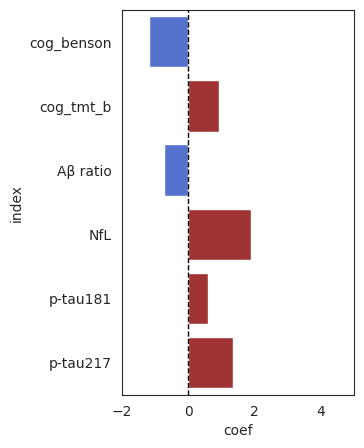

In [ ]:
X_ols_all = df_ad_ftd[k_feature]

y_ols = df_ad_ftd['diagnosis']


df_directions = pd.DataFrame()

for i in X_ols_all.columns:

    X_ols = X_ols_all[[i]]
    X_train, X_test, y_train, y_test = train_test_split(X_ols, y_ols, test_size=0.1, random_state=42)

    scaler = MinMaxScaler((0.05, 0.95))
    X_train_scaled = scaler.fit_transform(X_ols)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_ols.columns, index=X_ols.index)


    X_test_scaled = scaler.transform(X_test)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    X_train_scaled['intercept'] = 1
    X_test_scaled['intercept'] = 1


    model = sm.OLS(y_ols, X_train_scaled).fit()

    df = pd.read_html(model.summary().tables[1].as_html(), header=0, index_col=0)[0]
    df = df.drop('intercept')
    df = df.reset_index()
    df = df.reindex(df['coef'].abs().sort_values(ascending=False).index)

    df_directions.loc[df.iloc[0,0], 'coef'] = df.iloc[0,1]
    df_directions.loc[df.iloc[0,0], 'p'] = df.iloc[0,4]*len(X_ols_all.columns)

df_directions = df_directions.reset_index()
plt.figure(figsize=(3, 5))
#sns.barplot(data=df_directions, y='index', x='coef', capsize=0.1)

df_directions['color'] = df_directions['coef'].apply(lambda x: 'red' if x > 0 else 'blue')


sns.barplot(x='coef', y='index', data=df_directions, hue='color', dodge=False, palette=['royalblue', 'firebrick'], orient='h' ,legend=False)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlim([-2, 5])

plt.savefig('main_SVM_AD_FTD_index_better_model_ATN_MRI.pdf', format='pdf', bbox_inches='tight', dpi=300)


In [ ]:
df_directions

,index,coef,p,color
0,cog_benson,-1.1741,0.000,blue
1,cog_tmt_b,0.9308,0.000,red
2,Aβ ratio,-0.7281,0.216,blue
3,NfL,1.8848,0.000,red
4,p-tau181,0.5882,0.102,red
5,p-tau217,1.3444,0.000,red


<ipython-input-32-fb8a0740333d>:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.07431966668808773' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coef_df_for_plot.loc[i, 'signed_importance'] = coef_df_for_plot.loc[i, 'Permutation'] * np.sign(sign)


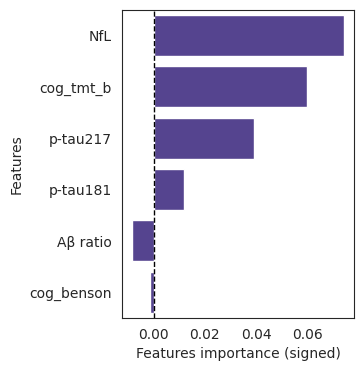

In [ ]:
#blue: #4E379C
# yellow: #F5A300
# red: #E32F2F

coef_df_for_plot = importancia_df
df_directions_for_plot = df_directions

coef_df_for_plot = coef_df_for_plot.set_index('Feature')
df_directions_for_plot = df_directions_for_plot.set_index('index')
list_coef = list(coef_df_for_plot.index)
coef_df_for_orig = coef_df_for_plot.copy()

# Create signed importance values
coef_df_for_plot['signed_importance'] = 0

for i in list_coef:
    sign = df_directions_for_plot.loc[i, 'coef']
    coef_df_for_plot.loc[i, 'signed_importance'] = coef_df_for_plot.loc[i, 'Permutation'] * np.sign(sign)

# Sort by absolute importance but plot with original signs
coef_df_for_plot_sort = coef_df_for_plot.iloc[:, :].sort_values(by='Permutation', ascending=False)
coef_df_for_plot_sort = coef_df_for_plot_sort[['Permutation', 'signed_importance']]
coef_df_for_plot_sort.reset_index(inplace=True)

plt.figure(figsize=(3, 4))

# Plot with original directions (negative to left, positive to right)
sns.barplot(
    x='signed_importance',
    y='Feature',
    data=coef_df_for_plot_sort,
    color='#4E379C',  # Pure blue color
    dodge=False,
    orient='h'
)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Features importance (signed)')
plt.ylabel('Features')
plt.savefig(
    'main_SVM_AD_FTD_feat_import_better_model_ATN_MRI_COGN2.pdf',
    format='pdf',
    bbox_inches='tight',
    dpi=300
)

### Shaps

In [ ]:
#explainer_ebm = shap.Explainer(model.predict, X)
#shap_values_ebm = explainer_ebm(X)

In [ ]:
#plt.subplots(figsize=(4, 9))

#shap.plots.beeswarm(shap_values_ebm, color="coolwarm", show=False, plot_size=[4,3.5])


#plt.savefig("Results/main_SVM_beeswarm_plot_CN_vs_AD.pdf", format="pdf", bbox_inches="tight")

### ROC curve

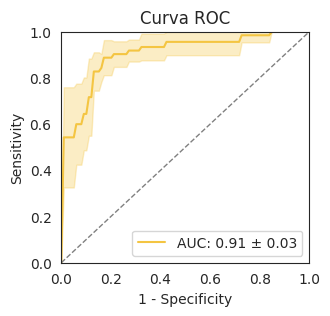

In [ ]:
c_fill = (245/255, 113/255, 130/255, 1)  # rgba(245, 113, 130, 0.1)
##606062 Blue
###f4c542 yellow
###ff4c4c red
c_line_main = '#f4c542'
c_dashed = "gray"  # reference line

plt.figure(figsize=(3.2, 3.0))
sns.set_style("white")

# shaded area between sup and inferior limits
plt.fill_between(mean_fpr, lower_tpr, upper_tpr, color=c_line_main, alpha=0.3)

# Main ROC curve
plt.plot(mean_fpr, mean_tpr, color=c_line_main, lw=1.5, label=f'AUC: {np.mean(auc_scores):.2f} ± {np.std(auc_scores):.2f}')

# Chance line
plt.plot([0, 1], [0, 1], linestyle="dashed", color=c_dashed, lw=1)


plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("Curva ROC")
plt.legend(loc="lower right")

# Save PDF
plt.savefig("ROC_main_SVM_CN_AD_better_model_ATN_MRI.pdf", format="pdf", bbox_inches="tight")
plt.show()